# Feature Engineering — Field Asset Health Monitor Project

Stage 4 of the pipeline. Consumes `sensor_readings.parquet` + `failure_windows.csv`
(D10 contract) and produces the **model-ready feature table** — one row per time
window, columns = engineered health features — plus its saved artifact.

**Specification (from stage 3's feed-forward):**
- Features in BOTH directions: rising duty/oil (gradual leaks, F4-type) AND
  idle/low-duty indicators (step failures, F1-type).
- Multi-scale look-backs (hours → days; F3's faint signal, if any, is early).
- State-occupancy features (fraction of time per Motor_current mode), not just
  central tendency (6.4).
- Dynamics/variability features — F3's only remaining chance (OQ5).
- Instrument-health features as a separate axis (antiphase, rolling variance).
- Gap-aware: no window may bridge a recording gap.
- Train/eval design per D19: features must carry the label so healthy-only
  training and two-target evaluation are possible downstream.

In [8]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from fahm import preprocessing as pp
from fahm import plotting as pl
from fahm import analysis as an
from fahm import features as ft          # NEW package module (see below)

cfg = pp.load_config("../configs/config.yaml")
df = pp.load_processed(cfg)
fw = pd.read_csv(cfg["paths"]["failure_windows"],
                 parse_dates=["start", "end", "maintenance"])
gaps = pp.find_gaps(df, cfg)
labels = an.label_windows(df, fw,
    degraded_periods=[("2020-04-18", "2020-04-30")],
    invalid_periods=[("2020-04-20 04:45", "2020-04-21 01:30")])
print(df.shape, "| labels:", dict(labels.value_counts()))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(1516948, 16) | labels: {'healthy': np.int64(1341222), 'degraded': np.int64(71443), 'prefail': np.int64(59014), 'infail': np.int64(21297), 'postrepair': np.int64(17837), 'invalid': np.int64(6135)}


## 1. Design: the feature grid

Decisions to make and log BEFORE building (D20):
- **Window size** for the feature rows (candidate: 1h — fine enough for
  48h-precursor dynamics, coarse enough that 175 days ≈ 4,200 rows).
- **Gap rule:** windows are computed within contiguous segments only; a
  window crossing a gap > threshold is dropped (stage-1 gap inventory).
- **Look-back scales** for rolling features (candidate: 6h / 24h / 168h).
- **Window label** = majority label of its samples (invalid wins on any
  overlap — trust rule).

### 1.1 Building the window grid

Features are computed per **time window**, not per raw sample — one row of the
feature table summarizes one window. The grid defines those windows.

The one rule that shapes everything: **no window may bridge a recording gap.**
A window spanning a 20-hour hole would average across a discontinuity and
produce meaningless features. So we first split the record into contiguous
**segments** (a new segment begins at every gap > threshold, reusing the
`find_gaps` logic), then tile 1-hour windows *within* each segment. Windows are
therefore 1h from each segment's start — not clock-aligned — a deliberate
consequence of gap-awareness (D20).

In [9]:
grid = ft.build_window_grid(df, cfg)        # window_start | window_end | segment_id

In [10]:
grid

,window_start,window_end,segment_id
0,2020-02-01 00:00:00,2020-02-01 01:00:00,0
1,2020-02-01 01:00:00,2020-02-01 02:00:00,0
2,2020-02-01 02:00:00,2020-02-01 03:00:00,0
3,2020-02-01 03:00:00,2020-02-01 04:00:00,0
4,2020-02-01 04:00:00,2020-02-01 05:00:00,0
...,...,...,...
4055,2020-08-31 15:42:31,2020-08-31 16:42:31,329
4056,2020-08-31 16:42:31,2020-08-31 17:42:31,329
4057,2020-08-31 17:42:31,2020-08-31 18:42:31,329
4058,2020-08-31 18:42:31,2020-08-31 19:42:31,329


### 1.2 Are the windows densely populated?

A 1-hour window holds ~360 samples at the 10s grid — *if* the data is dense.
Windows near sparse stretches could contain too few samples for reliable
features (a std over 5 points is noise). We count actual samples per window
before trusting the grid: a feature built on an under-filled window is a
silent poison.

In [11]:
# how many actual samples fall in each window? flag the thin ones
counts = []
for _, w in grid.iterrows():
    counts.append(an.window_mask(df, w["window_start"], w["window_end"]).sum())
grid["n_samples"] = counts
print(grid["n_samples"].describe())
print("windows with <60 samples (<10 min of data):", (grid["n_samples"] < 60).sum())

count    4060.000000
mean      360.537931
std        12.821256
min       297.000000
25%       363.000000
50%       363.000000
75%       363.000000
max       364.000000
Name: n_samples, dtype: float64
windows with <60 samples (<10 min of data): 0


### 1.3 Labeling each window

Each window inherits a label from its samples (from stage 3's `label_windows`):
the **majority** row-label, with one override — **`invalid` wins any overlap**.
A single frozen-sensor sample corrupts every feature in the window (mean, std,
slope all pulled toward the stuck value), so a window touching the Apr 20
instrument fault is distrusted wholesale rather than majority-voted. This costs
~2 boundary windows and guarantees no partially-frozen window enters training
(D20 trust rule).

In [12]:
grid_labels = ft.label_grid(grid, labels, df)     # majority label per window

In [13]:
display(grid_labels.head(),grid_labels.tail())
display(grid_labels.value_counts())

0    healthy
1    healthy
2    healthy
3    healthy
4    healthy
Name: label, dtype: str

4055    healthy
4056    healthy
4057    healthy
4058    healthy
4059    healthy
Name: label, dtype: str

label
healthy       3586
degraded       190
prefail        160
infail          56
postrepair      48
invalid         20
Name: count, dtype: int64

In [14]:
# the invalid windows should fall in April, inside the degraded span
inval = grid[grid_labels == "invalid"]
print(inval["window_start"].min(), "→", inval["window_start"].max())

2020-04-20 04:36:50 → 2020-04-20 23:36:50


**Grid built and validated.** 4,060 windows across 332 segments (= 331 gaps + 1),
all densely populated (min 297 samples, 0 thin windows). Label balance mirrors
the row level — healthy 88.3%, with degraded > prefail (the 12-day OQ3 span vs
pooled 48h precursors). The 20 `invalid` windows correspond to the ~20.5h Apr 20
fault at 1h resolution, confined to Apr 20–21 as the priority rule requires.

## 2. Feature families — build one, inspect it, then the next

#### GATE: does duty actually have daily / weekly rhythm? (D22)
If flat, calendar features encode a pattern that isn't there — drop the family.

In [15]:
# GATE: does duty have daily / weekly rhythm? (D22)  — computed WITHOUT mutating df standalone Series, not a df column
hour = df[pp.TIMESTAMP].dt.hour
dow = df[pp.TIMESTAMP].dt.dayofweek

by_hour = df["DV_eletric"].groupby(hour).mean()
by_dow = df["DV_eletric"].groupby(dow).mean()
print("duty by hour:\n", by_hour.round(3))
print("\nduty by day-of-week (0=Mon):\n", by_dow.round(3))
print(f"\nhour spread: {by_hour.max() - by_hour.min():.3f} | dow spread: {by_dow.max() - by_dow.min():.3f}")

duty by hour:
 timestamp
0     0.182
1     0.183
2     0.172
3     0.153
4     0.161
5     0.157
6     0.156
7     0.163
8     0.164
9     0.153
10    0.164
11    0.157
12    0.160
13    0.152
14    0.155
15    0.160
16    0.161
17    0.159
18    0.163
19    0.152
20    0.148
21    0.158
22    0.167
23    0.166
Name: DV_eletric, dtype: float64

duty by day-of-week (0=Mon):
 timestamp
0    0.146
1    0.133
2    0.193
3    0.138
4    0.139
5    0.191
6    0.190
Name: DV_eletric, dtype: float64

hour spread: 0.035 | dow spread: 0.060


#### Calendar gate (D22) — family DROPPED, one thread opened
- Hour-of-day: flat (spread 0.035, no daytime/rush pattern) — the APU's load
  does not follow passenger-demand time-of-day. Rush-hour detrend hypothesis
  refuted. No hour features.
- Day-of-week: irregular (spread 0.060) — Wed/Sat/Sun elevated ~0.19 vs ~0.14,
  but NOT a weekday/weekend rhythm. Reads as specific operational events on
  particular days, not a cyclic feature.
- Decision: DROP calendar_features (nothing to cyclically encode or detrend).
  Family count 7 -> 6.

In [16]:
# OQ6 confounding check: same, healthy-only
healthy = labels == "healthy"
by_dow_healthy = df.loc[healthy, "DV_eletric"].groupby(dow[healthy]).mean()
print("healthy-only duty by dow:\n", by_dow_healthy.round(3))
print(f"spread: {by_dow_healthy.max() - by_dow_healthy.min():.3f}")

healthy-only duty by dow:
 timestamp
0    0.130
1    0.134
2    0.188
3    0.143
4    0.123
5    0.116
6    0.168
Name: DV_eletric, dtype: float64
spread: 0.072


### OQ6 (resolved, partially) — day-of-week duty
- Original Wed/Sat/Sun elevation was PART confound: Saturday's high duty was
  the degraded/failure periods leaking in (healthy-only: 0.191 → 0.116 — an
  OQ3 fingerprint). But Wed (0.188) and Sun (0.168) stay elevated on
  HEALTHY-only data vs ~0.13 baseline — a real ~0.05 effect, cause unknown
  (scheduled ops on those days?).
- Consequence: minor. Healthy duty has a small day-of-week baseline
  (~0.13–0.19). Too small to justify calendar features (failure signals are
  10-40x larger), but noted as a residual baseline a duty anomaly score could
  in principle correct for. calendar_features stays DROPPED.

### Examine the rest of the families
Discipline: after each family, inspect its NEW columns (describe + a glance)
BEFORE adding the next. A broken family (all-NaN, wrong scale, degenerate) is
caught immediately, not buried among others. The per-failure effect-size
validation is consolidated in §3; the inline check here is basic sanity.

| family | features (examples) | catches |
|---|---|---|
| **duty & state occupancy** | duty; frac time in motor modes | F4 up, F1 down, 6.4's mode story |
| **pressure dynamics** | TP3 idle-decay slope; cycles/hour | the leak physics directly |
| **thermal** | oil median, oil trend, oil-per-duty | F4 ramp, F1 cool-idle |
| **variability (F3's chance)** | rolling std duty/oil; cycle-duration var | erratic-before-failing (OQ5) |
| **cycle frequency** | Lomb-Scargle dominant freq + drift (D21) | leak-driven rhythm change; F3 long shot |
| **instrument health** | antiphase share; stuck-analog flags | Apr 20-type faults; trust mask |

#### duty & state occupancy

In [17]:
f_duty_state = ft.duty_state_features(df, grid, cfg)

In [18]:
f_duty_state

,duty,frac_off,frac_offloaded,frac_loaded
0,0.057692,0.807692,0.137363,0.054945
1,0.027548,0.763085,0.209366,0.027548
2,0.055096,0.713499,0.231405,0.055096
3,0.057851,0.713499,0.228650,0.057851
4,0.057692,0.714286,0.228022,0.057692
...,...,...,...,...
4055,0.115702,0.528926,0.355372,0.115702
4056,0.165289,0.438017,0.399449,0.162534
4057,0.120879,0.475275,0.409341,0.115385
4058,0.154270,0.493113,0.358127,0.148760


In [19]:
display(f_duty_state.describe())          # sanity: scale sane? any all-NaN column?

,duty,frac_off,frac_offloaded,frac_loaded
count,4060.000000,4060.000000,4060.000000,4060.000000
mean,0.161419,0.547244,0.295922,0.156834
std,0.207123,0.203049,0.136945,0.211595
min,0.000000,0.000000,0.000000,0.000000
25%,0.071625,0.473829,0.228650,0.071625
50%,0.110193,0.559229,0.308540,0.107438
75%,0.143251,0.695055,0.354396,0.137741
max,1.000000,1.000000,1.000000,1.000000


quick glance on the histograms: 

array([[<Axes: title={'center': 'duty'}>,
        <Axes: title={'center': 'frac_off'}>],
       [<Axes: title={'center': 'frac_offloaded'}>,
        <Axes: title={'center': 'frac_loaded'}>]], dtype=object)

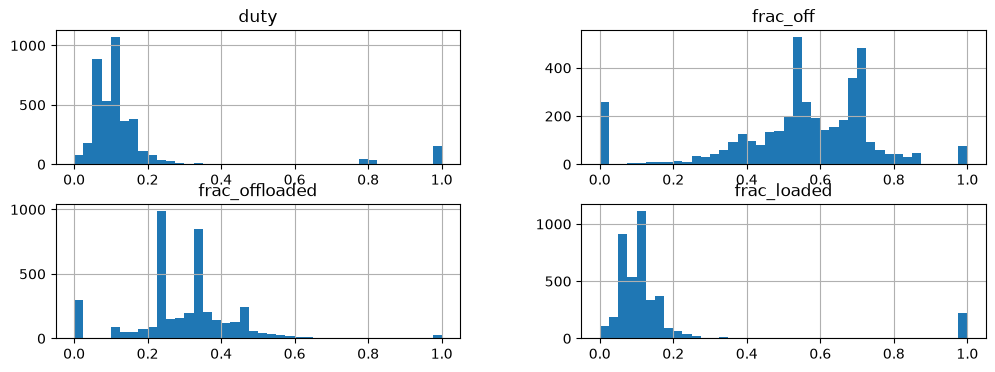

In [20]:
f_duty_state.hist(bins=40, figsize=(12,4))

- frac_ distributions are multi-modal with spikes at 0/1 — windows often sit entirely in one machine state
- the 1.0 spike in frac_loaded is the infail population.

Does duty_state separate failures? (the real test, per-failure)

In [21]:
feat_cols = ["duty", "frac_off", "frac_offloaded", "frac_loaded"]
duty_feats = pd.concat([grid, f_duty_state], axis=1)
an.feature_effect_by_failure(f_duty_state, grid, grid_labels, fw, feat_cols)

,duty,frac_off,frac_offloaded,frac_loaded
F1,-0.64,0.73,-0.72,-0.66
F2,0.26,-0.27,0.29,0.26
F3,0.08,0.17,-0.16,0.13
F4,3.46,-1.64,0.71,2.28


**duty_state — strong, and better than raw sensors.** Windowed effect sizes
far exceed the raw-sensor values (F4 duty +3.46 vs raw +0.136; F1 −0.64 vs
−0.078) — aggregation concentrates signal the per-sample metric diluted.
F1 shows the full inverse signature (frac_off +0.73, everything else down —
idle before a step); F4 the full forward one (duty +3.46, frac_loaded +2.28).
F2 mild (~0.27). F3 remains silent (≤0.17 on every feature) — not in duty or
state occupancy; deferred entirely to dynamics/spectral families (OQ5).

Lets have a look on pressure dynamics:

In [22]:
f_pressure_dynamics = ft.pressure_dynamics_features(df, grid)

In [23]:
f_pressure_dynamics

,tp3_decay_slope,cycles_per_hour
0,-0.000985,21
1,-0.001004,10
2,-0.000985,20
3,-0.000993,21
4,-0.001174,21
...,...,...
4055,-0.002237,42
4056,-0.002130,60
4057,-0.002138,44
4058,-0.002033,56


In [24]:
display(f_pressure_dynamics.describe())          # sanity: scale sane? any all-NaN column?

,tp3_decay_slope,cycles_per_hour
count,3.841000e+03,4060.000000
mean,-1.639683e-03,57.506897
std,8.009209e-04,72.099362
min,-1.840462e-02,0.000000
25%,-1.957683e-03,26.000000
50%,-1.585508e-03,40.000000
75%,-1.123012e-03,52.000000
max,4.799001e-17,364.000000


quick glance on pressure dynamics histograms:

array([[<Axes: title={'center': 'tp3_decay_slope'}>,
        <Axes: title={'center': 'cycles_per_hour'}>]], dtype=object)

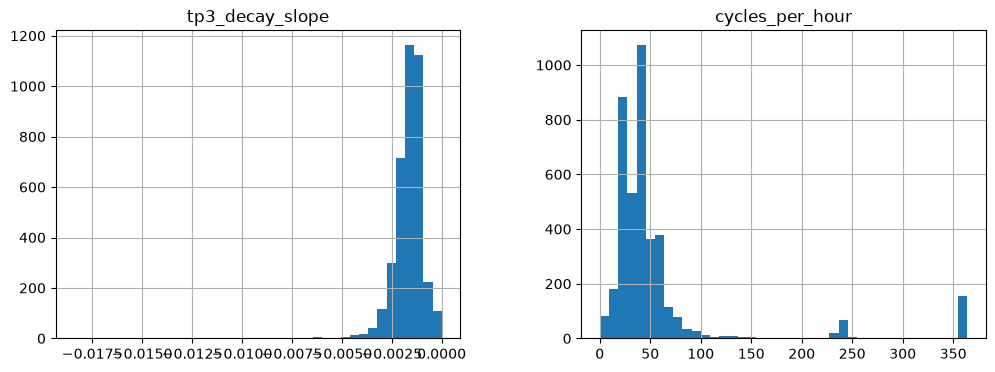

In [25]:
display(f_pressure_dynamics.hist(bins=40, figsize=(12,4)))

In [26]:
feat_cols = ["tp3_decay_slope", "cycles_per_hour"]
an.feature_effect_by_failure(f_pressure_dynamics, grid, grid_labels, fw, feat_cols)   # your promoted validator

,tp3_decay_slope,cycles_per_hour
F1,0.75,-0.64
F2,-0.42,0.26
F3,0.12,0.08
F4,-1.69,3.44


**pressure_dynamics — strong, after a granularity fix (L15).** tp3_decay_slope
(median per-idle-stretch fit) is the direct leak meter: F4 −1.69 (steeper decay
= leaking), F2 −0.42, F1 +0.75 (shallower — the idle signature again). Physics
confirmed: all slopes negative (pressure always decays when off), steepening
before leaks. cycles_per_hour: F4 +3.44 (rapid pre-failure cycling). F3 silent
on both (+0.12, +0.08) — the leak meter itself can't see F3.

Lets have a look in the thermal features:

In [27]:
f_thermal = ft.thermal_features(df, grid)
f_thermal

,oil_median,oil_trend
0,52.1375,-0.000461
1,52.3500,-0.000268
2,52.2250,0.000202
3,51.8250,0.000293
4,52.6000,0.000334
...,...,...
4055,66.6000,0.000377
4056,67.5500,-0.000184
4057,66.9625,-0.000699
4058,65.0750,-0.000307


In [28]:
display(f_thermal.describe())          # sanity: scale sane? any all-NaN column?

,oil_median,oil_trend
count,4060.000000,4060.000000
mean,62.197691,0.000084
std,5.683091,0.000926
min,39.150000,-0.004765
25%,57.612500,-0.000395
50%,62.850000,0.000003
75%,66.106250,0.000490
max,87.150000,0.010549


quick glance on the thermal features histograms:

array([[<Axes: title={'center': 'oil_median'}>,
        <Axes: title={'center': 'oil_trend'}>]], dtype=object)

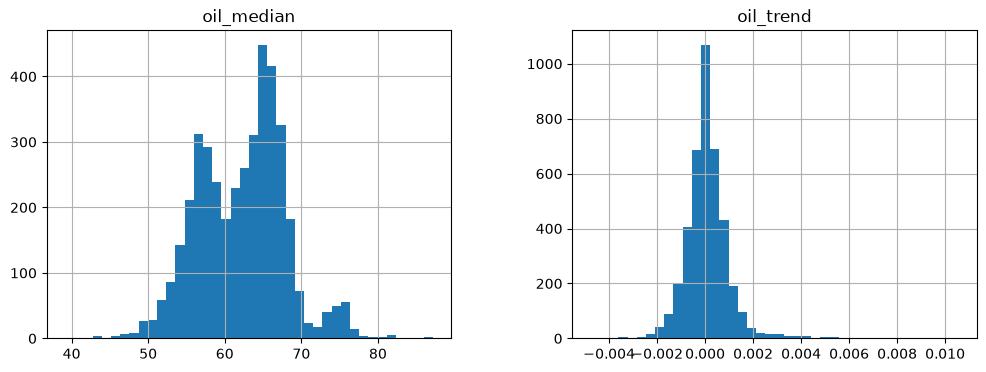

In [29]:
display(f_thermal.hist(bins=40, figsize=(12,4)))

In [30]:
feat_cols = ["oil_median", "oil_trend"]
an.feature_effect_by_failure(f_thermal, grid, grid_labels, fw, feat_cols)

,oil_median,oil_trend
F1,-1.12,-0.01
F2,0.52,-0.01
F3,0.09,-0.02
F4,0.84,0.14


### Thermal residual — separating "hot because busy" from "hot because faulty"

Raw `oil_median` is ambiguous: oil runs hot both when the machine legitimately
works hard (high duty) AND when a fault causes overheating. To isolate the
fault signal we remove the workload effect.

**Method (D26):** on **healthy windows only**, fit the natural relationship
between oil temperature and duty — the scatter below shows it's a clear rising
curve (oil climbs with duty, then plateaus), so a degree-2 fit captures it.
This curve is "the oil temperature a healthy machine runs at, for a given
workload."

For every window we then compute the **residual**: observed oil minus what the
healthy curve predicts at that window's duty. A positive residual means *hotter
than the workload explains* — the leak signature — independent of how hard the
machine is working.

This replaces the earlier `oil_per_duty` ratio, which conflated numerator and
denominator (and blew up at small duty). A residual is the right tool whenever
you want "more/less than context predicts" — the same pattern used later for
forecast-residual anomaly detection (D23).

In [31]:
oil_residual = ft.oil_residual_feature(f_thermal, duty_feats, grid_labels)
oil_residual

0      -6.648727
1      -4.574204
2      -6.404599
3      -6.970793
4      -6.186227
          ...   
4055    4.496589
4056    2.888755
4057    4.580098
4058    0.960044
4059   -1.666361
Name: oil_median, Length: 4060, dtype: float64

In [33]:
display(oil_residual.describe())

count    4060.000000
mean       -0.040959
std         4.158584
min       -23.930961
25%        -2.652632
50%         0.560422
75%         2.819528
max        17.847453
Name: oil_median, dtype: float64

Text(0.5, 1.0, 'healthy oil vs duty — baseline')

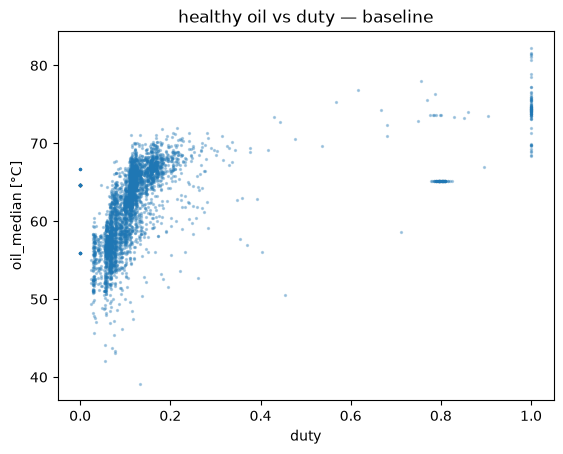

In [35]:
h = grid_labels == "healthy"
plt.scatter(duty_feats.loc[h, "duty"], f_thermal.loc[h, "oil_median"], s=2, alpha=0.3)
plt.xlabel("duty"); plt.ylabel("oil_median [°C]"); plt.title("healthy oil vs duty — baseline")

In [43]:
f_thermal2 = f_thermal.assign(oil_residual=oil_residual)
an.feature_effect_by_failure(f_thermal2, grid, grid_labels, fw, ["oil_median", "oil_trend", "oil_residual"])

,oil_median,oil_trend,oil_residual
F1,-1.12,-0.01,-1.23
F2,0.52,-0.01,0.64
F3,0.09,-0.02,0.20
F4,0.84,0.14,0.04


**Reading the residual effects:** F1 −1.23 (cooler than its idle workload
predicts) and F2 +0.64 (genuinely hotter than expected) are real thermal
anomalies. **F4 ≈ 0 is the informative result:** F4's oil is high in absolute
terms (oil_median +0.84), but the residual shows it's *exactly what its very
high duty predicts* — F4's heat is workload-driven, not excess. The residual
correctly finds "no unexplained heat" for F4, sending F4's detectable signal to
the duty/cycling features instead. A feature returning ≈0 here is working
correctly, not failing.

**thermal — oil_median + oil_trend + oil_residual, each distinct.**
- oil_median: F1 −1.12 (cool idle), F4 +0.84 (hot) — but F4's heat is
  workload-driven (see residual).
- oil_trend: isolates F4's ramp (+0.14).
- oil_residual (oil vs healthy oil-duty baseline, D26): F1 −1.23, F2 +0.64 —
  GENUINE thermal anomalies; F4 +0.04 ≈ zero, meaning F4's high oil is fully
  explained by its high duty, NOT excess heat. The residual correctly removed
  the workload confound the ratio (oil_per_duty) muddled.
- F3 silent on all (≤0.20).

#### Lets have a look at variability features —
 this is F3's interrogation, so I'll flag which feature is its best hope. The premise: a machine becoming erratic before failing shows up in spread and rhythm-instability, not in levels (which is why every level/rate feature has been flat for F3)

In [52]:
f_variability = ft.variability_features(df, grid)
f_variability

,oil_std,tp3_std,duty_std,cycle_dur_cv,cycle_dur_trend,longest_load_stretch,frac_continuous_load
0,1.242349,0.535723,0.233482,NaN,NaN,1.833333,0.057692
1,1.081632,0.517593,0.163900,NaN,NaN,1.666667,0.027548
2,1.219688,0.555459,0.228483,NaN,NaN,1.666667,0.055096
3,1.241392,0.582471,0.233784,NaN,NaN,1.833333,0.057851
4,1.111599,0.560519,0.233482,NaN,NaN,1.833333,0.057692
...,...,...,...,...,...,...,...
4055,3.119274,0.563607,0.320309,NaN,NaN,2.666667,0.115702
4056,3.201651,0.598188,0.371954,0.184522,-98.5,2.833333,0.165289
4057,3.199625,0.540050,0.326435,NaN,NaN,2.500000,0.120879
4058,3.191794,0.633020,0.361706,0.168151,15.0,2.500000,0.154270


In [53]:
display(f_variability.describe())          # sanity: scale sane? any all-NaN column?

,oil_std,tp3_std,duty_std,cycle_dur_cv,cycle_dur_trend,longest_load_stretch,frac_continuous_load
count,4060.000000,4060.000000,4060.000000,896.000000,896.000000,4060.000000,4060.000000
mean,3.203884,0.541492,0.290133,0.311319,4.869072,5.029023,0.161419
std,1.360272,0.190353,0.092498,0.346390,225.331668,11.541774,0.207123
min,0.000000,0.000000,0.000000,0.000000,-966.000000,0.000000,0.000000
25%,2.711957,0.546340,0.253583,0.091304,-63.750000,2.166667,0.071625
50%,3.542670,0.574416,0.310097,0.191343,0.040073,2.500000,0.110193
75%,4.036660,0.593973,0.338912,0.357952,67.064286,2.833333,0.143251
max,13.972302,3.167456,0.500416,1.956088,911.500000,60.666667,1.000000


quick glance on variability features histogram:

array([[<Axes: title={'center': 'oil_std'}>,
        <Axes: title={'center': 'tp3_std'}>,
        <Axes: title={'center': 'duty_std'}>],
       [<Axes: title={'center': 'cycle_dur_cv'}>,
        <Axes: title={'center': 'cycle_dur_trend'}>,
        <Axes: title={'center': 'longest_load_stretch'}>],
       [<Axes: title={'center': 'frac_continuous_load'}>, <Axes: >,
        <Axes: >]], dtype=object)

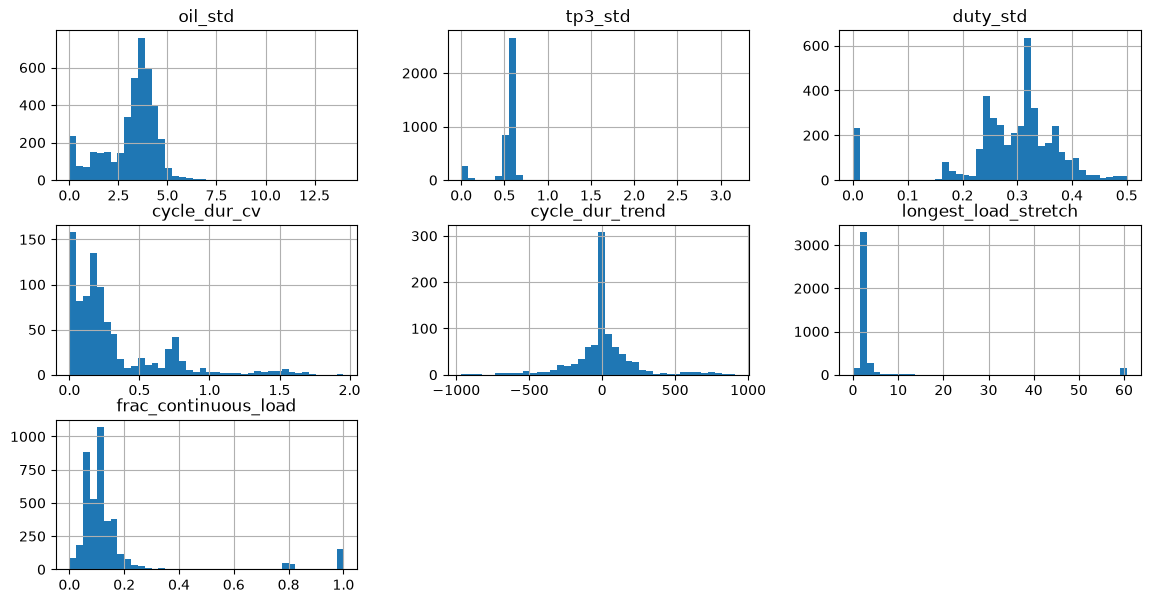

In [54]:
f_variability.hist(bins=40, figsize=(14,7))

In [57]:
var_cols = ["oil_std", "tp3_std", "duty_std", "cycle_dur_cv",
            "cycle_dur_trend", "longest_load_stretch"]
an.feature_effect_by_failure(f_variability, grid, grid_labels, fw, var_cols)

,oil_std,tp3_std,duty_std,cycle_dur_cv,cycle_dur_trend,longest_load_stretch
F1,0.45,-0.58,-0.79,2.54,-1.47,-0.33
F2,-0.27,0.00,0.26,-0.07,-0.39,0.67
F3,0.31,0.10,0.09,2.12,-1.46,0.67
F4,-0.47,0.69,1.72,-0.56,0.02,1.83


In [51]:
# WHY is each window NaN? decompose it.
diag = pd.DataFrame({"label": grid_labels})
for i, w in grid.iterrows():
    seg = df[(df[pp.TIMESTAMP] >= w["window_start"]) & (df[pp.TIMESTAMP] < w["window_end"])]
    n_cycles = (seg["DV_eletric"].diff() == 1).sum()
    diag.loc[i, "n_cycles"] = n_cycles
    diag.loc[i, "duty"] = seg["DV_eletric"].mean()

# the two kinds of "no cycles":
print("idle windows (duty<0.05, few cycles):", ((diag.duty < 0.05) & (diag.n_cycles < 3)).sum())
print("locked-loaded (duty>0.8, few cycles):", ((diag.duty > 0.8) & (diag.n_cycles < 3)).sum())
print("cyclable (>=3 cycles):", (diag.n_cycles >= 3).sum())

idle windows (duty<0.05, few cycles): 261
locked-loaded (duty>0.8, few cycles): 161
cyclable (>=3 cycles): 2314


**variability — separates the failures by MECHANISM, and catches F3 via cycle
dynamics.**
- cycle_dur_cv + cycle_dur_trend: F1 (+2.54/−1.47) and F3 (+2.12/−1.46) show
  erratic AND shortening cycles — cycling instability. This is F3's ONLY
  signal (silent on all level/rate/thermal features) → F3 is a
  cycling-instability failure, not a level or lock-up one.
- longest_load_stretch: F4 +1.83 (locks into continuous load), F2 +0.67; F3
  only +0.67 → F3 does NOT lock up (my regime hypothesis refuted). F4 is the
  lock-up failure; F3 is the short-cycling failure — opposite regimes.
- CAVEAT (unchanged): cycle dynamics NaN on ~78% of windows; F3's signal rests
  on 6 measurable pre-window points. Real but coverage-limited.
- oil_std/tp3_std weak; duty_std tracks duty.

In [1]:
rows = []
for _, w in grid.iterrows():
    seg = df[(df[pp.TIMESTAMP] >= w["window_start"]) & (df[pp.TIMESTAMP] < w["window_end"])]
    rows.append({
        "n_cycles": (seg["DV_eletric"].diff() == 1).sum(),
        "duty": seg["DV_eletric"].mean(),
    })
diag = pd.DataFrame(rows, index=grid.index)
diag["label"] = grid_labels

print("idle (duty<0.05, <3 cycles):   ", ((diag.duty < 0.05) & (diag.n_cycles < 3)).sum())
print("locked (duty>0.8, <3 cycles):  ", ((diag.duty > 0.8) & (diag.n_cycles < 3)).sum())
print("cyclable (>=3 cycles):         ", (diag.n_cycles >= 3).sum())

NameError: name 'grid' is not defined

In [ ]:
pre_f3 = (grid["window_start"] >= fw.loc[2,"start"] - pd.Timedelta(hours=48)) & (grid["window_start"] < fw.loc[2,"start"])
print("pre-F3 windows:", pre_f3.sum(), "| with cycle_dur_cv:", f_variability.loc[pre_f3,"cycle_dur_cv"].notna().sum())
print("with duty:", f_variability.loc[pre_f3,"duty_std"].notna().sum())
print("with cycles_per_hour:", f_variability.loc[pre_f3,"cycles_per_hour"].notna().sum())


pre-F3 windows: 45 | with cycle_dur_cv: 6


KeyError: 'duty'

**variability — F3 signal is suggestive but n-limited, and points to a better
feature.** cycle_dur_cv gave F3 +2.12 — BUT only 6 of 45 pre-F3 windows had
enough cycles to compute it. The reason is the finding: ~87% of pre-F3 windows
run near-continuously loaded (too few cycles to measure variability). So F3's
precursor is the machine LEAVING its cycling regime (locking into continuous
load), which cycle_dur_cv can't capture where it matters. F1 also +2.54 (more
robust — more measurable windows). CANDIDATE FIX (stage 4b/5): a
cycling-regime feature defined even at zero cycles — e.g. longest
continuous-load stretch or frac-time-in-continuous-load — to catch F3 across
all windows, not just the cyclable few.

### OQ5 (update) — F3 detectability
- F3 is invisible to all level/rate/trend/thermal features. cycle_dur_cv hints
  at erratic cycling (+2.12) but on only 6/45 pre-F3 windows — the rest run
  continuously loaded. F3's real precursor appears to be a REGIME SHIFT (normal
  cycling → continuous load) rather than a measurable level or variability.
- Next: a regime feature defined at zero cycles (longest load-stretch /
  frac-continuous). If that separates F3 robustly, F3 is detectable-as-regime;
  if not, F3 is confirmed sudden. The spectral family (cycle_frequency) is a
  parallel test — but it shares the same "needs cycles" limitation.

In [ ]:
# cycle_frequency
f_cycle_frequency = ft.cycle_frequency_features(df, grid)
display(f_cycle_frequency.describe())          # sanity: scale sane? any all-NaN column?
# quick glance: f_cycle_frequency.hist(bins=40, figsize=(12,4)) or per-column as needed

In [ ]:
# instrument_health
f_instrument_health = ft.instrument_health_features(df, grid)
display(f_instrument_health.describe())          # sanity: scale sane? any all-NaN column?
# quick glance: f_instrument_health.hist(bins=40, figsize=(12,4)) or per-column as needed

In [ ]:
# assemble all families onto the grid (build_features runs FAMILIES in order)
feats = ft.build_features(df, grid, cfg)
feats["label"] = grid_labels
print(feats.shape); feats.columns.tolist()

## 3. Feature validation — do engineered features separate better than raw?

The stage-3 effect-size machinery, now pointed at the features:
per-failure effect sizes of each feature family. Success criterion:
- F4/F1 signals at least as strong as raw sensors gave;
- **any F3 signal at all** in the variability family would be new information;
- instrument-health features fire on the Apr 20 window and nowhere unexpected.

In [ ]:
# an.prefail_effect_by_failure(feats_df, fw, feature_cols, grid_labels, hours=48)
# ... and 168h

## 4. Save the feature artifact

`features.parquet`: one row per window — features + label + window bounds.
The single input for stage 5 (modeling). Path in config (D11 convention).

In [ ]:
# path = ft.save_features(feats, cfg)

## Findings feed-forward (to stage 5 — modeling)
- feature table: <n windows x m features>, artifact at <path>
- which families separate, per failure: <...>
- F3 verdict after dynamics features: <detectable / confirmed sudden>
- instrument-health mask coverage: <...>
- training set definition: windows labeled healthy AND instrument-clean